In [1]:
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

![](https://github.com/StrixzIV/01416417-deep-learning-and-application/blob/main/assets/IMG_7885.JPG?raw=true)

In [2]:
# section 1
# Hyperparameters

learning_rate = 1e-3
batch_size = 128
num_epochs = 50

In [3]:
# section 2
# Load the MNIST dataset, normalize pixel values to [0, 1], and reshape for CNN (28, 28, 1)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [4]:
# section 3
# Split the training set into a training set and a validation set (9:1 ratio) with shuffle
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [ ]:
# section 4
# Define a CNN model architecture

num_classes = 10

model = Sequential([
    
    Input(shape=(28, 28, 1)),
    
    # 1st convolution
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # 2nd convolution
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

	# Flatten 2D pixels into 1D flat vector
    Flatten(),
    
    # MLP for feature extraction
    Dense(128, activation='relu', kernel_initializer=initializers.GlorotUniform()),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')

])

In [6]:
# section 5
# print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# section 6
# Define loss
loss = 'sparse_categorical_crossentropy'

In [8]:
# section 7
# Define an optimizer
optimizer = Adam(learning_rate=learning_rate)

In [9]:
# Callbacks: Early Stopping & Reduce Learning Rate on Plateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [10]:
# section 8
# compile the model
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [11]:
# section 9
# Image Augmentation & Training with Shuffle
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

train_generator = datagen.flow(x_train, y_train, batch_size=batch_size, shuffle=True)

history = model.fit(
    train_generator,
    epochs=num_epochs,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    shuffle=True
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9208 - loss: 0.2602 - val_accuracy: 0.7472 - val_loss: 0.7436 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9692 - loss: 0.1016 - val_accuracy: 0.9873 - val_loss: 0.0451 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9760 - loss: 0.0778 - val_accuracy: 0.9583 - val_loss: 0.1275 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9793 - loss: 0.0672 - val_accuracy: 0.9785 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9818 - loss: 0.0593
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9822 - loss: 0.0582 - val_accuracy: 0.9858 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9856 - los

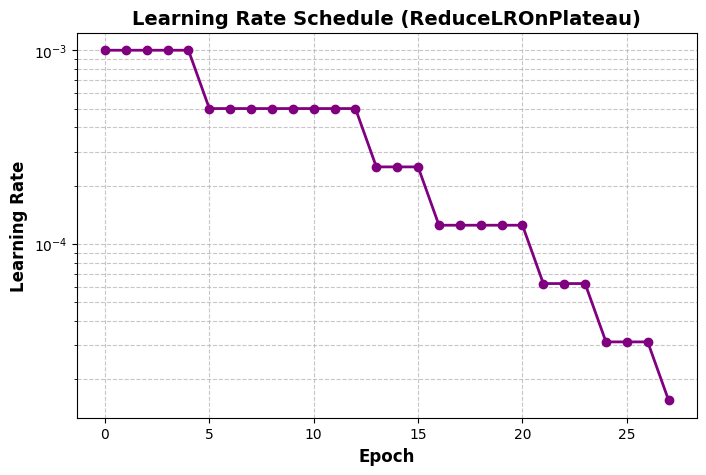

In [13]:
# Plot the change in learning rate across epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['learning_rate'], marker='o', color='purple', linewidth=2)
plt.title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Learning Rate', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [14]:
# section 10
# evaluate test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'test_acc: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9949 - loss: 0.0152
test_acc: 0.9949


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Confusion Matrix:
[[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1131    1    0    0    0    0    3    0    0]
 [   1    0 1028    1    0    0    0    1    1    0]
 [   0    0    0 1007    0    1    0    1    1    0]
 [   0    0    0    0  977    0    0    0    1    4]
 [   0    0    0    5    0  885    1    0    0    1]
 [   2    3    0    0    0    2  949    0    2    0]
 [   0    0    2    0    2    0    0 1023    1    0]
 [   0    0    0    1    0    1    0    2  970    0]
 [   0    0    0    1    3    0    0    3    2 1000]]

Misclassified samples: 51


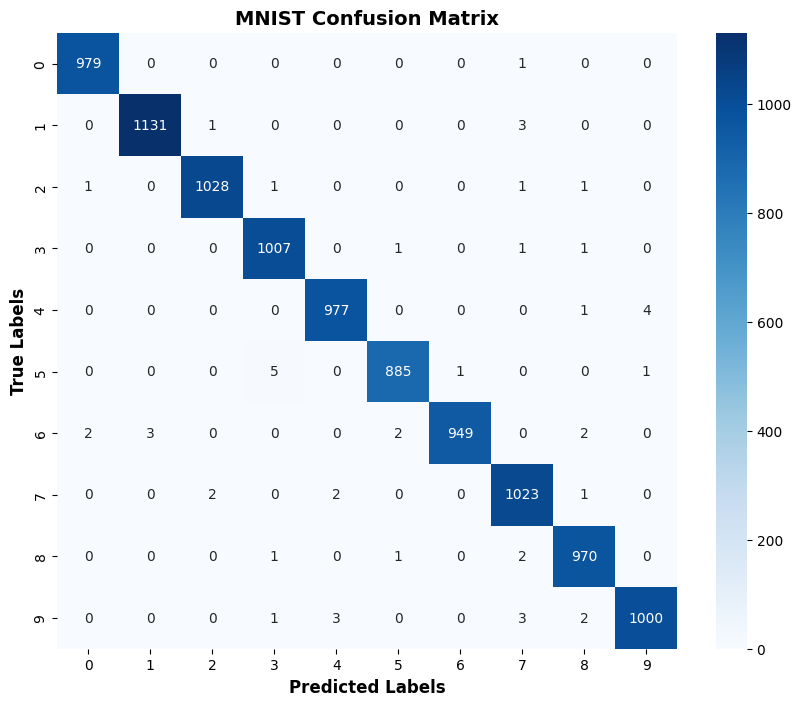

In [15]:
# Bonus No.2 - Confusion Matrix Summary (Mandatory Print & Heatmap)

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

n_misclassified = 0

for (i, row) in enumerate(cm):
    for (j, e) in enumerate(row):
        if (i == j):
            continue
        n_misclassified += e

print(f'\nMisclassified samples: {n_misclassified}')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')

plt.show()